**STEP-1: Install Required Libraries**

In [1]:
!pip install beautifulsoup4
!pip install wordcloud
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 109.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


**STEP-2: Import Required Libraries**

In [2]:
import requests
from bs4 import BeautifulSoup

import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud

**STEP-3: Scrape Webpage Content**

In [3]:
url = "https://www.indiatoday.in/india/story/pm-modi-us-state-visit-joe-biden-indian-community-events-2393380-2023-06-15"

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

text = soup.get_text()

print(text[:1000])

The Long Game: Modi visit set to transform India-US ties - India Today India TodayAaj TakIndia Today HindiNewsTakGNTTVLallantopBusiness TodayBanglaMalayalamNortheastBT BazaarHarper's BazaarSports TakCrime TakAstro TakGamingBrides TodayCosmopolitanKisan TakIshq FMReader’s DigestIndia TodayAaj TakIndia Today HindiNewsTakGNTTVLallantopBusiness TodayBanglaMalayalamNortheastBT BazaarMagazineLive TVSearchSEARCHSIGN INEdition ININUSHome TVLive TVPrimetimeMagazineLatest EditionInsightBest CollegesIndia Today HindiJobsIndiaBusinessAll Business NewsShare MarketIPOPersonal FinanceCompaniesElection HubElectionsTamil Nadu ElectionKerala ElectionWest Bengal ElectionPuducherry ElectionAssam ElectionTamil Nadu ScheduleKerala ScheduleWest Bengal SchedulePuducherry ScheduleAssam ScheduleLife+StylePuzzlesSouthGlobalAll World NewsUS NewsCanada NewsUK NewsChina NewsIndians Abroad SportsAll SportsT20 World CupCricketT20 World Cup ScheduleT20 World Cup Points TableLive ScoreFootballTennisTechnologyShowbuzzEn

**STEP-4: Generate Word Cloud**

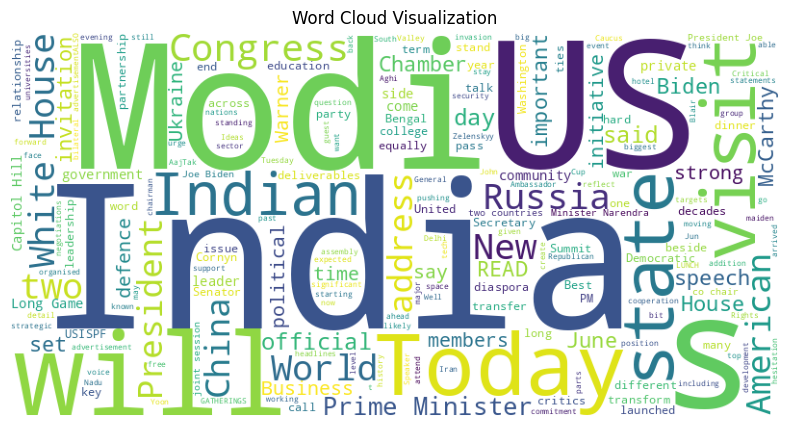

In [4]:
wordcloud = WordCloud(
                width=800,
                height=400,
                background_color='white'
            ).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud Visualization")
plt.show()

**STEP-5: Top 10 Most Frequent Words**

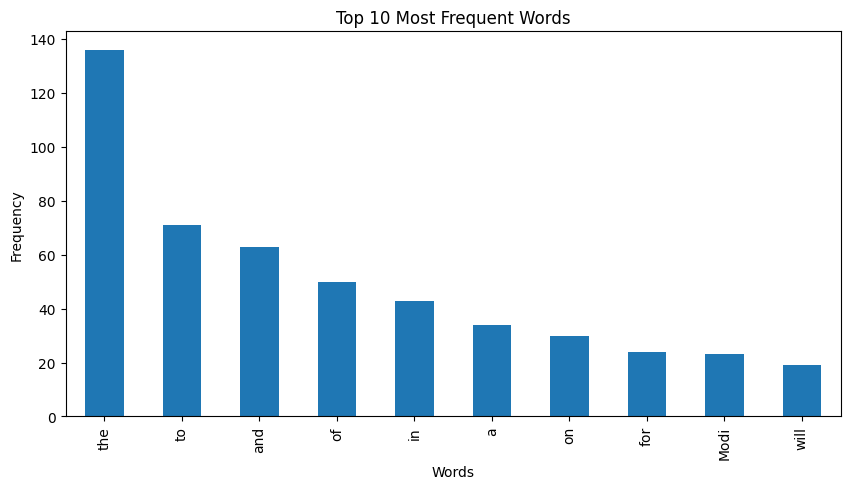

In [5]:
word_frequency = pd.Series(text.split()).value_counts().head(10)

plt.figure(figsize=(10,5))
word_frequency.plot(kind="bar")

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent Words")

plt.show()

**STEP-6: Named Entity Recognition (NER)**

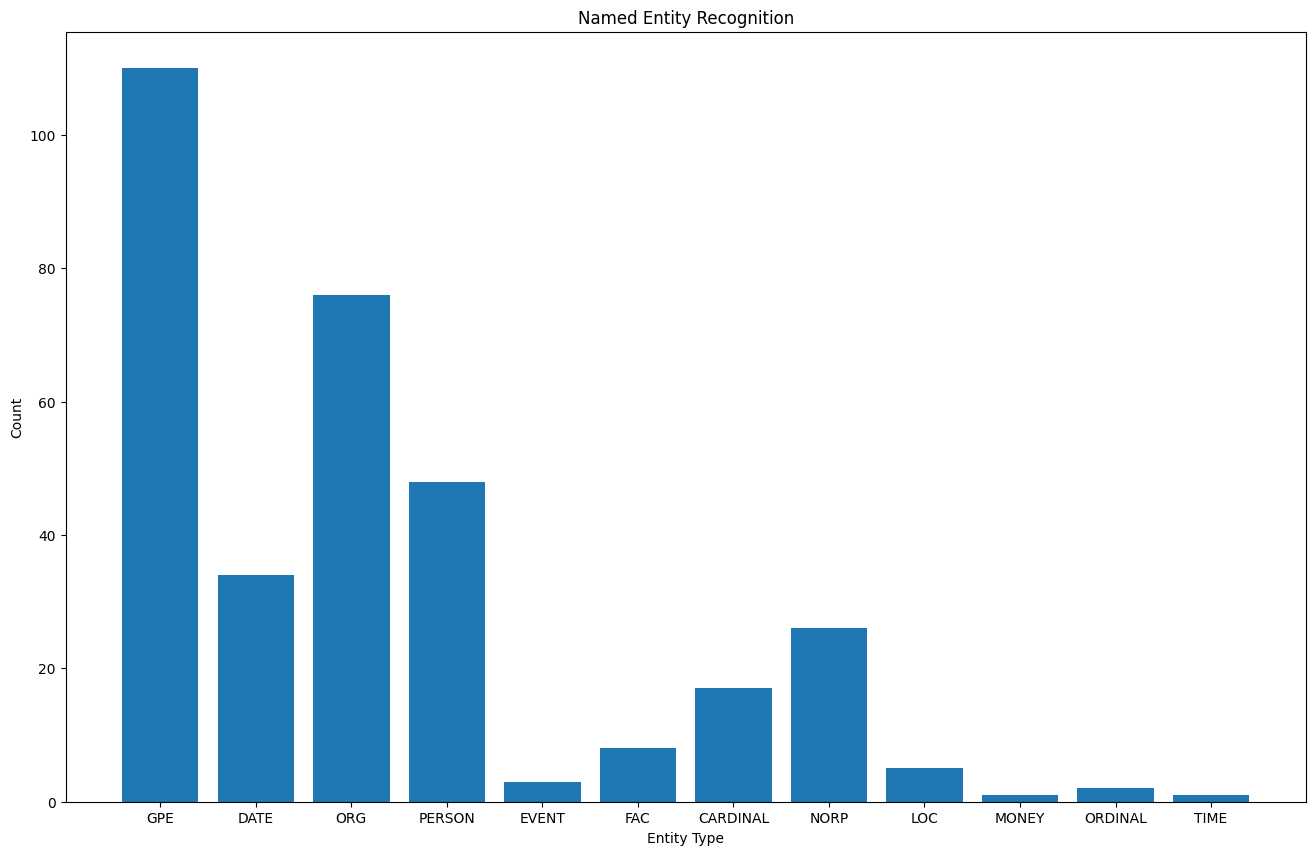

In [7]:
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm")

doc = nlp(text)

entities = [ent.label_ for ent in doc.ents]

entity_counts = dict(Counter(entities))

plt.figure(figsize=(16,10))

plt.bar(entity_counts.keys(), entity_counts.values())

plt.xlabel("Entity Type")
plt.ylabel("Count")
plt.title("Named Entity Recognition")

plt.show()

**STEP-7: Sentiment Analysis**

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


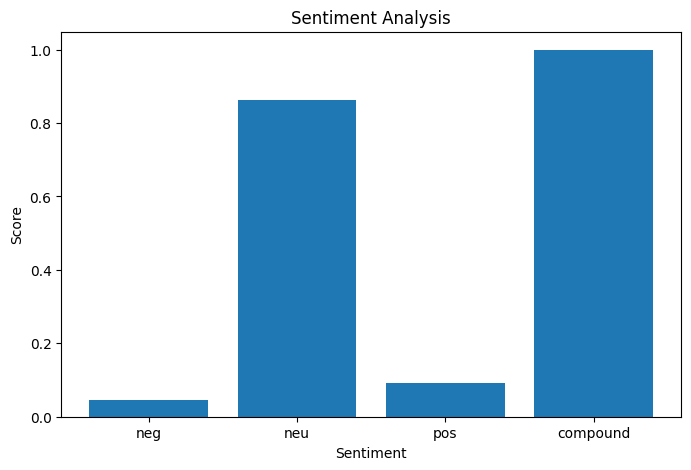

In [8]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

sentiment_scores = sia.polarity_scores(text)

plt.figure(figsize=(8,5))

plt.bar(sentiment_scores.keys(), sentiment_scores.values())

plt.xlabel("Sentiment")
plt.ylabel("Score")
plt.title("Sentiment Analysis")

plt.show()